# Climate Correlation Analysis

**Research question:** Does antecedent precipitation (from ERA5 reanalysis) correlate with the flood extent captured in each Sen1Floods11 event?

For each of the 11 flood events in the dataset, we pull 14 days of daily precipitation
leading up to the Sentinel-1 acquisition date (from ERA5, via the Open-Meteo Historical
Weather API), and compare total/max precipitation against the ground-truth flood extent
(% water pixels) for that event.

**Scope note:** this is a single-snapshot correlation across 11 events, not a
continuous time-series trend analysis (the dataset only contains one labeled date per
event, 2016-2019). It tests whether heavier antecedent rainfall is associated with
larger detected flood extent across events — a modest, honest first step toward
connecting flood detection to climate variables.

In [1]:
import sys
sys.path.append('../src')

import glob
import os
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from scipy import stats

METADATA_PATH = '../data/sen1floods11/v1.1/Sen1Floods11_Metadata.geojson'
LABEL_DIR = '../data/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand'

colors = ['#5B82AD', '#D0A52A', '#B85C5C', '#966BB5', '#2A958E', '#7A7A7A', '#333333']

## 1. Load event metadata

In [2]:
events = gpd.read_file(METADATA_PATH)
events['centroid'] = events.geometry.centroid
events['lat'] = events['centroid'].y
events['lon'] = events['centroid'].x
events[['ID', 'location', 's1_date', 'lat', 'lon']]

/var/folders/l0/jdg4bp7x7n7_9s355c6l3bqc0000gn/T/ipykernel_930/4153863601.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  events['centroid'] = events.geometry.centroid


,ID,location,s1_date,lat,lon
0,1,Bolivia,2018-02-15,-13.675144,-64.998950
1,12,Colombia,2018-08-22,4.605932,-67.847957
2,2,Ghana,2018-09-18,9.120139,-1.042854
3,3,India,2016-08-12,26.565953,93.157001
4,4,Cambodia,2018-08-05,12.423061,105.251065
5,5,Nigeria,2018-09-21,7.326974,5.740953
6,6,Pakistan,2017-06-28,31.196872,70.771838
7,7,Paraguay,2018-10-31,-24.913086,-56.619013
8,8,Somalia,2018-05-07,3.927749,45.394701
9,9,Spain,2019-09-17,38.537699,0.054753


## 2. Compute Ground-Truth Flood Extent per Event

Averaging % water pixels across all chips belonging to each event (multiple 512x512
chips can belong to the same flood event).

In [3]:
def flood_extent_for_event(location_name):
    """Average % water pixels across all label chips for a given event/location."""
    pattern = os.path.join(LABEL_DIR, f'{location_name}_*_LabelHand.tif')
    label_files = glob.glob(pattern)

    if not label_files:
        return None, 0

    water_pcts = []
    for f in label_files:
        with rasterio.open(f) as src:
            label = src.read(1)
        valid = label != -1
        if valid.sum() == 0:
            continue
        water_pct = (label[valid] == 1).sum() / valid.sum() * 100
        water_pcts.append(water_pct)

    return np.mean(water_pcts), len(label_files)

extents = []
for _, row in events.iterrows():
    mean_extent, n_chips = flood_extent_for_event(row['location'])
    extents.append({'location': row['location'], 'mean_flood_extent_pct': mean_extent, 'n_chips': n_chips})

extent_df = pd.DataFrame(extents)
extent_df

,location,mean_flood_extent_pct,n_chips
0,Bolivia,16.992148,15
1,Colombia,NaN,0
2,Ghana,7.103248,53
3,India,12.834634,68
4,Cambodia,NaN,0
5,Nigeria,22.266594,18
6,Pakistan,7.575380,28
7,Paraguay,9.432627,67
8,Somalia,6.172385,26
9,Spain,14.135955,30


## 3. Fetch Antecedent Precipitation from ERA5 (via Open-Meteo)

For each event, pull daily precipitation for the 14 days leading up to the Sentinel-1
acquisition date. No API key required, Open-Meteo serves ERA5 reanalysis data openly.

In [4]:
def fetch_precipitation(lat, lon, end_date, days_before=14):
    """Fetch daily precipitation (mm) for the N days leading up to end_date."""
    end_date = pd.to_datetime(end_date)
    start_date = end_date - pd.Timedelta(days=days_before)

    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': start_date.strftime('%Y-%m-%d'),
        'end_date': end_date.strftime('%Y-%m-%d'),
        'daily': 'precipitation_sum',
        'timezone': 'UTC',
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    precip = data['daily']['precipitation_sum']
    precip = [p if p is not None else 0.0 for p in precip]
    return {
        'total_precip_mm': sum(precip),
        'max_daily_precip_mm': max(precip),
        'dates': data['daily']['time'],
        'daily_values': precip,
    }

climate_records = []
for _, row in events.iterrows():
    result = fetch_precipitation(row['lat'], row['lon'], row['s1_date'])
    climate_records.append({
        'location': row['location'],
        's1_date': row['s1_date'],
        'total_precip_mm': result['total_precip_mm'],
        'max_daily_precip_mm': result['max_daily_precip_mm'],
    })

climate_df = pd.DataFrame(climate_records)
climate_df

,location,s1_date,total_precip_mm,max_daily_precip_mm
0,Bolivia,2018-02-15,226.4,44.9
1,Colombia,2018-08-22,144.5,29.9
2,Ghana,2018-09-18,107.7,41.1
3,India,2016-08-12,209.1,38.8
4,Cambodia,2018-08-05,129.7,34.2
5,Nigeria,2018-09-21,157.0,79.8
6,Pakistan,2017-06-28,56.2,15.2
7,Paraguay,2018-10-31,128.2,34.7
8,Somalia,2018-05-07,87.7,16.9
9,Spain,2019-09-17,85.9,36.5


## 4. Merge and Correlate

In [5]:
merged = climate_df.merge(extent_df, on='location')
merged = merged.dropna(subset=['mean_flood_extent_pct'])
merged

,location,s1_date,total_precip_mm,max_daily_precip_mm,mean_flood_extent_pct,n_chips
0,Bolivia,2018-02-15,226.4,44.9,16.992148,15
2,Ghana,2018-09-18,107.7,41.1,7.103248,53
3,India,2016-08-12,209.1,38.8,12.834634,68
5,Nigeria,2018-09-21,157.0,79.8,22.266594,18
6,Pakistan,2017-06-28,56.2,15.2,7.575380,28
7,Paraguay,2018-10-31,128.2,34.7,9.432627,67
8,Somalia,2018-05-07,87.7,16.9,6.172385,26
9,Spain,2019-09-17,85.9,36.5,14.135955,30
10,Sri-Lanka,2017-05-30,37.2,10.9,11.235719,42
11,USA,2019-05-22,130.5,50.1,4.582941,69


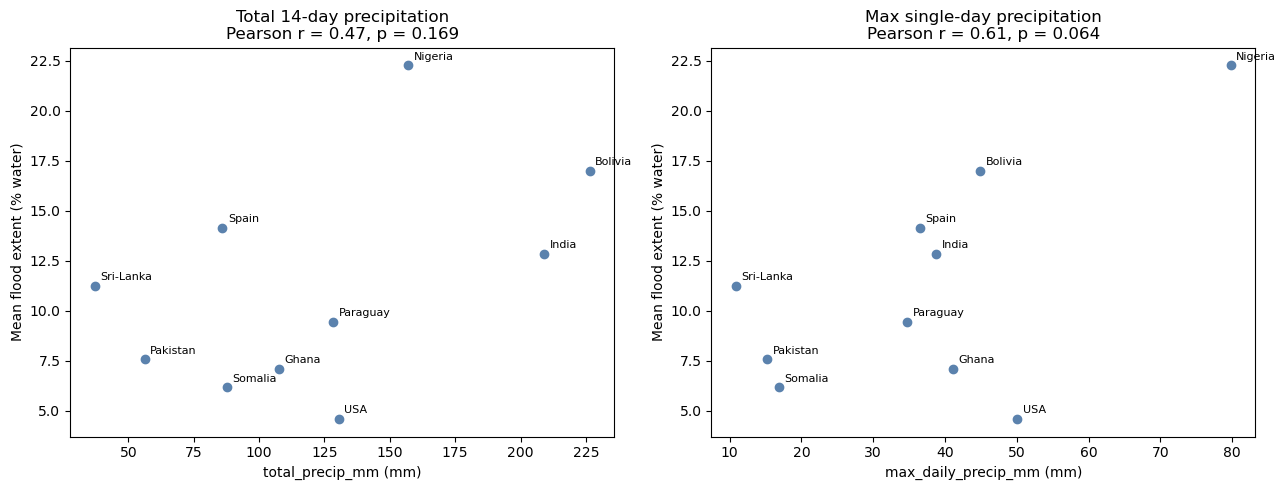

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, precip_col, title in zip(
    axes,
    ['total_precip_mm', 'max_daily_precip_mm'],
    ['Total 14-day precipitation', 'Max single-day precipitation']
):
    ax.scatter(merged[precip_col], merged['mean_flood_extent_pct'], color=colors[0])
    for _, row in merged.iterrows():
        ax.annotate(row['location'], (row[precip_col], row['mean_flood_extent_pct']),
                     fontsize=8, xytext=(4, 4), textcoords='offset points')

    r, p = stats.pearsonr(merged[precip_col], merged['mean_flood_extent_pct'])
    ax.set_title(f'{title}\nPearson r = {r:.2f}, p = {p:.3f}')
    ax.set_xlabel(f'{precip_col} (mm)')
    ax.set_ylabel('Mean flood extent (% water)')

plt.tight_layout()
plt.show()

## 5. Key Takeaways

- A **positive relationship** is visible **between antecedent precipitation and detected 
  flood extent**: max single-day precipitation shows a moderate correlation (r = 0.61, 
  p = 0.064), just short of conventional significance thresholds. Total 14-day 
  precipitation shows a weaker relationship (r = 0.47, p = 0.169).
- With only n=10 events, **this analysis is exploratory**, not confirmatory,a couple 
  of outlier points could meaningfully shift these correlations, and no correction 
  for multiple comparisons was applied.
- The **USA event is a notable outlier**: high total precipitation (130mm) but low 
  flood extent (4.6%), plausibly reflecting drainage infrastructure, terrain, or 
  a mismatch between the precipitation window and the actual flood peak.
- **Two events (Colombia, Cambodia) were excluded** because they have no hand-labeled 
  chips in this dataset (only present in the weakly-labeled subset, which was 
  excluded from this project for label quality reasons), leaving n=10 of the 
  original 12 metadata entries for this analysis.
- This is a **single-snapshot correlation**, not a time-series trend. A genuine 
  climate-change analysis would require repeated observations of the same regions 
  over many years, which this dataset does not provide.